# Data Vortex A'26 — Round 2
## Rebuilding the Social Engine: Self-contained NLP Model

This notebook develops, selects, trains, evaluates, saves, and validates separate sentiment and topic classifiers from the supplied labelled social-post dataset. Duplicate-normalized posts are grouped before splitting to prevent leakage.

**Primary task:** sentiment classification (`sentiment_label`)  
**Secondary task:** topic classification (`topic_category`)

In [1]:
# 1. Imports and reproducibility configuration
from pathlib import Path
from time import perf_counter
import json, re, unicodedata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from IPython.display import display
from sklearn.model_selection import GroupShuffleSplit
from sklearn.dummy import DummyClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)

SEED = 42
# Works when launched at the repository root or from notebooks/.
ROOT = Path.cwd().resolve()
if not (ROOT / 'data').exists() and (ROOT.parent / 'data').exists():
    ROOT = ROOT.parent
DATA_PATH = ROOT / 'data' / 'Labeled_Social_NLP_Training_Data.csv'
RESULTS = ROOT / 'results'; FIGURES = ROOT / 'figures'; MODELS = ROOT / 'models'
for folder in [RESULTS, FIGURES, MODELS]:
    folder.mkdir(exist_ok=True)
print('Input:', Path('data/Labeled_Social_NLP_Training_Data.csv'))
print('Random seed:', SEED)

Input: data\Labeled_Social_NLP_Training_Data.csv
Random seed: 42


## Dataset loading and audit

The dataset is inspected rather than assumed. Text normalization below is solely for duplicate detection and grouping; model features use the original post text.

In [2]:
# 2. Dataset loading, quality checks, and duplicate-label consistency
df = pd.read_csv(DATA_PATH)
required = {'text_id', 'post_text', 'sentiment_label', 'topic_category'}
assert required.issubset(df.columns), f'Missing required columns: {required - set(df.columns)}'
assert df['post_text'].notna().all(), 'Missing post text requires a documented handling decision.'
targets = ['sentiment_label', 'topic_category']

def normalize_for_duplicate_detection(text):
    value = unicodedata.normalize('NFKC', str(text or '')).lower().strip()
    return re.sub(r'\s+', ' ', value)

df['duplicate_group'] = df['post_text'].map(normalize_for_duplicate_detection)
text_lengths = df['post_text'].astype(str).str.len()
group_sizes = df['duplicate_group'].value_counts()
consistent = {target: int((df.groupby('duplicate_group')[target].nunique() > 1).sum()) for target in targets}
audit = pd.DataFrame({
    'measurement': ['Rows', 'Columns', 'Missing values (all columns)', 'Exact duplicate rows',
                    'Rows in duplicate normalized-text groups', 'Repeated normalized-text groups',
                    'Empty/whitespace text', 'Duplicate groups with conflicting sentiment labels',
                    'Duplicate groups with conflicting topic labels'],
    'value': [len(df), df.shape[1] - 1, int(df.drop(columns='duplicate_group').isna().sum().sum()),
              int(df.drop(columns='duplicate_group').duplicated().sum()), int(df['duplicate_group'].duplicated(keep=False).sum()),
              int((group_sizes > 1).sum()), int(df['post_text'].astype(str).str.strip().eq('').sum()),
              consistent['sentiment_label'], consistent['topic_category']]
})
display(audit)
print('Schema:'); display(df.drop(columns='duplicate_group').dtypes.to_frame('dtype'))
print('Text-length summary (characters):'); display(text_lengths.describe(percentiles=[.25,.5,.75,.95]).to_frame().T)
for target in targets:
    print(f'\n{target} distribution:')
    display(df[target].value_counts().rename_axis(target).reset_index(name='posts'))
assert all(v == 0 for v in consistent.values()), 'Conflicting duplicate labels need investigation before training.'

,measurement,value
0,Rows,9000
1,Columns,4
2,Missing values (all columns),0
3,Exact duplicate rows,0
4,Rows in duplicate normalized-text groups,2087
5,Repeated normalized-text groups,987
6,Empty/whitespace text,0
7,Duplicate groups with conflicting sentiment la...,0
8,Duplicate groups with conflicting topic labels,0


Schema:


,dtype
text_id,str
post_text,str
sentiment_label,str
topic_category,str


Text-length summary (characters):


,count,mean,std,min,25%,50%,75%,95%,max
post_text,9000.0,107.985778,26.104963,25.0,91.0,113.0,129.0,142.0,180.0



sentiment_label distribution:


,sentiment_label,posts
0,Negative,3000
1,Positive,3000
2,Neutral,3000



topic_category distribution:


,topic_category,posts
0,Community_Discussion,7752
1,Technical_Issues,815
2,Feature_Feedback,297
3,Account_Security,136


## Leakage-safe train / validation / test split

A 20% group-held-out test partition is created first. A second group split places 12.5% of remaining groups in validation, producing approximately 70/10/20 rows. No identical normalized text may appear across partitions.

In [3]:
# 3. Group-aware split. The primary target provides split stratification context; grouping is enforced.
primary_target = 'sentiment_label'
groups = df['duplicate_group']
gss_test = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=SEED)
trainval_idx, test_idx = next(gss_test.split(df, df[primary_target], groups))
gss_val = GroupShuffleSplit(n_splits=1, test_size=0.125, random_state=SEED + 1)
train_rel, val_rel = next(gss_val.split(df.iloc[trainval_idx], df.iloc[trainval_idx][primary_target], groups.iloc[trainval_idx]))
train_idx, val_idx = trainval_idx[train_rel], trainval_idx[val_rel]
splits = {'train': train_idx, 'validation': val_idx, 'test': test_idx}
group_sets = {name: set(groups.iloc[idx]) for name, idx in splits.items()}
intersections = {f'{a} / {b}': len(group_sets[a] & group_sets[b]) for a,b in [('train','validation'),('train','test'),('validation','test')]}
split_summary = pd.DataFrame({'partition': list(splits), 'rows': [len(x) for x in splits.values()]})
display(split_summary)
display(pd.DataFrame({'partition_pair': list(intersections), 'shared_normalized_text_groups': list(intersections.values())}))
assert not any(intersections.values()), 'Leakage detected: duplicate group crosses a split boundary.'

,partition,rows
0,train,6316
1,validation,890
2,test,1794


,partition_pair,shared_normalized_text_groups
0,train / validation,0
1,train / test,0
2,validation / test,0


## Models, vectorization, and metrics

The baseline and candidate models use TF-IDF word unigrams/bigrams. Original social text is retained: punctuation, casing, emojis, URLs, mentions, and hashtags can contribute lexical signal. The vectorizer belongs inside each pipeline and is fitted only on training data.

In [4]:
# 4. Reusable, self-contained model and evaluation functions
def make_candidates():
    def vectorizer():
        return TfidfVectorizer(ngram_range=(1, 2), min_df=2, max_df=0.98, sublinear_tf=True, strip_accents='unicode')
    return {
        'Majority baseline': Pipeline([('tfidf', vectorizer()), ('classifier', DummyClassifier(strategy='most_frequent'))]),
        'TF-IDF + Logistic Regression': Pipeline([('tfidf', vectorizer()), ('classifier', LogisticRegression(C=2.0, max_iter=2000, class_weight='balanced', random_state=SEED))]),
        'TF-IDF + Linear SVM': Pipeline([('tfidf', vectorizer()), ('classifier', LinearSVC(C=1.0, class_weight='balanced', random_state=SEED))]),
    }

def evaluate_predictions(y_true, y_pred, labels):
    macro_p, macro_r, macro_f1, _ = precision_recall_fscore_support(y_true, y_pred, average='macro', zero_division=0)
    weighted_f1 = precision_recall_fscore_support(y_true, y_pred, average='weighted', zero_division=0)[2]
    return {
        'accuracy': float(accuracy_score(y_true, y_pred)), 'macro_precision': float(macro_p),
        'macro_recall': float(macro_r), 'macro_f1': float(macro_f1), 'weighted_f1': float(weighted_f1),
        'classification_report': classification_report(y_true, y_pred, labels=labels, output_dict=True, zero_division=0),
        'confusion_matrix': confusion_matrix(y_true, y_pred, labels=labels)
    }

def train_timed(pipeline, x, y):
    start = perf_counter(); pipeline.fit(x, y); return pipeline, perf_counter() - start

## Validation comparison, selection, final training, and held-out evaluation

Each target is a separate supervised task. The selected model is the candidate with the highest validation macro F1; weighted F1 is only a tie-breaker. The test partition remains untouched until after this decision.

In [5]:
# 5. Full training/evaluation workflow for each labelled target
def run_target(target):
    labels = sorted(df[target].astype(str).unique())
    x_train = df.iloc[splits['train']]['post_text'].astype(str); y_train = df.iloc[splits['train']][target].astype(str)
    x_val = df.iloc[splits['validation']]['post_text'].astype(str); y_val = df.iloc[splits['validation']][target].astype(str)
    x_test = df.iloc[splits['test']]['post_text'].astype(str); y_test = df.iloc[splits['test']][target].astype(str)

    candidates = make_candidates(); rows = []
    for name, pipeline in candidates.items():
        fitted, seconds = train_timed(pipeline, x_train, y_train)
        validation = evaluate_predictions(y_val, fitted.predict(x_val), labels)
        rows.append({'Model': name, 'Accuracy': validation['accuracy'], 'Macro Precision': validation['macro_precision'],
                     'Macro Recall': validation['macro_recall'], 'Macro F1': validation['macro_f1'],
                     'Weighted F1': validation['weighted_f1'], 'Training seconds': seconds})
    comparison = pd.DataFrame(rows).sort_values(['Macro F1', 'Weighted F1'], ascending=False).reset_index(drop=True)
    selected = comparison.loc[0, 'Model']

    # Freeze the validation decision, retrain selected complete pipeline on train+validation, then score test once.
    final_pipeline, final_seconds = train_timed(make_candidates()[selected], pd.concat([x_train, x_val]), pd.concat([y_train, y_val]))
    test_predictions = final_pipeline.predict(x_test)
    test_metrics = evaluate_predictions(y_test, test_predictions, labels)
    joblib.dump(final_pipeline, MODELS / f'{target}_pipeline.pkl')

    prediction_table = pd.DataFrame({'text_id': df.iloc[splits['test']]['text_id'], 'post_text': x_test,
                                     'actual_label': y_test, 'predicted_label': test_predictions})
    prediction_table['correct'] = prediction_table.actual_label.eq(prediction_table.predicted_label)
    if hasattr(final_pipeline, 'decision_function'):
        decision = np.asarray(final_pipeline.decision_function(x_test))
        prediction_table['confidence_proxy'] = decision.max(axis=1) if decision.ndim == 2 else np.abs(decision)
    errors = prediction_table.loc[~prediction_table.correct].copy()
    errors['text_length'] = errors.post_text.str.len()
    order = 'confidence_proxy' if 'confidence_proxy' in errors else 'text_length'
    errors = errors.sort_values(order, ascending=False)
    error_pairs = errors.groupby(['actual_label', 'predicted_label']).size().sort_values(ascending=False).reset_index(name='count')

    # Persist genuine generated artifacts for reproducibility.
    comparison.to_csv(RESULTS / f'model_comparison_{target}.csv', index=False)
    prediction_table.to_csv(RESULTS / f'predictions_{target}.csv', index=False)
    errors.head(25).to_csv(RESULTS / f'error_analysis_{target}.csv', index=False)
    error_pairs.to_csv(RESULTS / f'error_pairs_{target}.csv', index=False)
    serializable = {**test_metrics, 'confusion_matrix': test_metrics['confusion_matrix'].tolist(), 'target': target,
                    'final_model': selected, 'labels': labels, 'final_training_seconds': final_seconds}
    (RESULTS / f'metrics_{target}.json').write_text(json.dumps(serializable, indent=2), encoding='utf-8')
    return comparison, selected, test_metrics, errors, error_pairs, final_pipeline

runs = {}
for target in targets:
    comparison, selected, metrics, errors, pairs, pipeline = run_target(target)
    runs[target] = {'comparison': comparison, 'selected': selected, 'metrics': metrics, 'errors': errors, 'pairs': pairs, 'pipeline': pipeline}
    print(f'\n### {target}: validation model comparison')
    display(comparison.round(4))
    print('Selected final model:', selected)
    print('Held-out test metrics:')
    display(pd.DataFrame([{'Accuracy': metrics['accuracy'], 'Macro Precision': metrics['macro_precision'],
                           'Macro Recall': metrics['macro_recall'], 'Macro F1': metrics['macro_f1'],
                           'Weighted F1': metrics['weighted_f1']}]).round(4))


### sentiment_label: validation model comparison


,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1,Training seconds
0,TF-IDF + Logistic Regression,0.5809,0.5781,0.5759,0.5763,0.5833,0.7425
1,TF-IDF + Linear SVM,0.5708,0.5696,0.5662,0.5670,0.5736,0.3749
2,Majority baseline,0.2876,0.0959,0.3333,0.1489,0.1285,0.2668


Selected final model: TF-IDF + Logistic Regression
Held-out test metrics:


,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
0,0.5786,0.5817,0.5783,0.5795,0.58



### topic_category: validation model comparison


,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1,Training seconds
0,TF-IDF + Linear SVM,0.9146,0.8530,0.5128,0.5970,0.8951,0.7295
1,TF-IDF + Logistic Regression,0.9011,0.7336,0.5129,0.5842,0.8872,1.2842
2,Majority baseline,0.8494,0.2124,0.2500,0.2296,0.7803,0.2955


Selected final model: TF-IDF + Linear SVM
Held-out test metrics:


,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
0,0.9264,0.9147,0.4919,0.5805,0.911


## Per-class metrics, confusion matrices, and error analysis

All values below come from the final held-out predictions. Error tables are derived from all wrong predictions (the displayed examples are ordered consistently, not hand-picked).


## sentiment_label — final model: TF-IDF + Logistic Regression


,precision,recall,f1-score,support
Negative,0.6534,0.6150,0.6336,613.0
Neutral,0.4945,0.5328,0.5129,595.0
Positive,0.5972,0.5870,0.5921,586.0
macro avg,0.5817,0.5783,0.5795,1794.0
weighted avg,0.5824,0.5786,0.5800,1794.0


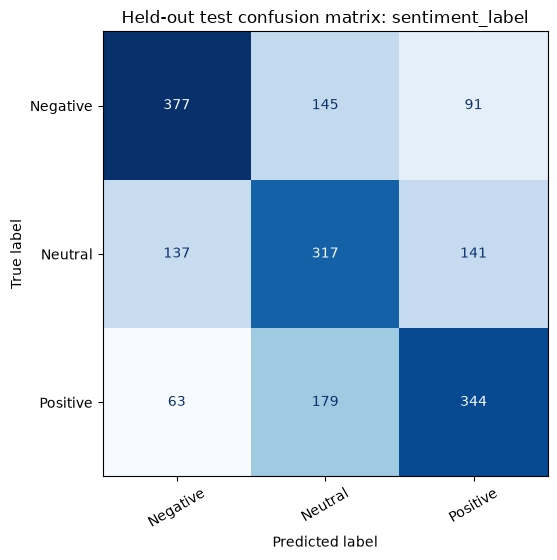

Most frequent confusion pairs:


,actual_label,predicted_label,count
0,Positive,Neutral,179
1,Negative,Neutral,145
2,Neutral,Positive,141
3,Neutral,Negative,137
4,Negative,Positive,91
5,Positive,Negative,63


Errors: 756 of 1794 held-out posts. Representative highest-margin/longest errors:


,actual_label,predicted_label,post_text
4229,Neutral,Negative,@user @user Does practice of ALMAJIRI in d nor...
6992,Neutral,Negative,"""If it weren't for Christians, the Aztecs woul..."
359,Positive,Neutral,[OSHODI] Oliseh delighted with Super Eagles te...
8187,Negative,Positive,Sharknado is definitely the best of the worst....
1590,Neutral,Negative,"""Was going to play DA but man I'm so fucking t..."
4908,Neutral,Positive,Would it be appropriate to have cake for Princ...
5827,Negative,Positive,@user wall to wall people on the platform at S...
7879,Neutral,Negative,"""It's a longshot, but if I were a betting man,..."
2903,Negative,Positive,@user naww U2 may not be the best band for you...
6886,Neutral,Negative,Northern elders ask Dasuki not to go to court ...



## topic_category — final model: TF-IDF + Linear SVM


,precision,recall,f1-score,support
Account_Security,0.8571,0.2308,0.3636,26.0
Community_Discussion,0.9234,0.9987,0.9596,1557.0
Feature_Feedback,0.8889,0.1569,0.2667,51.0
Technical_Issues,0.9894,0.5812,0.7323,160.0
macro avg,0.9147,0.4919,0.5805,1794.0
weighted avg,0.9273,0.9264,0.9110,1794.0


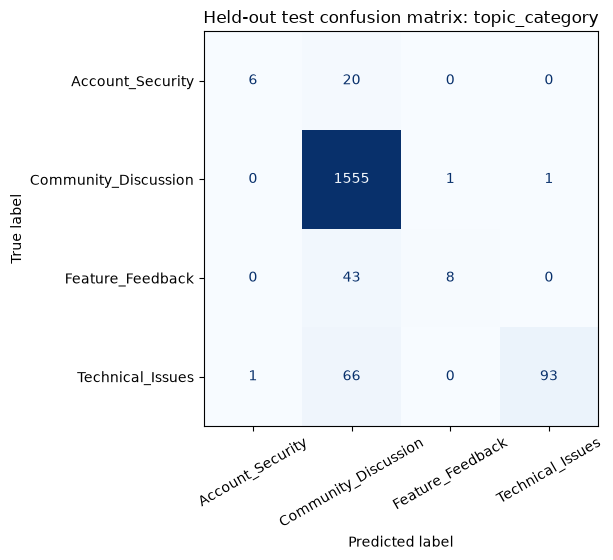

Most frequent confusion pairs:


,actual_label,predicted_label,count
0,Technical_Issues,Community_Discussion,66
1,Feature_Feedback,Community_Discussion,43
2,Account_Security,Community_Discussion,20
3,Community_Discussion,Feature_Feedback,1
4,Community_Discussion,Technical_Issues,1
5,Technical_Issues,Account_Security,1


Errors: 132 of 1794 held-out posts. Representative highest-margin/longest errors:


,actual_label,predicted_label,post_text
4412,Technical_Issues,Community_Discussion,"""Kanye West would make a better president than..."
3448,Account_Security,Community_Discussion,"""Totally worth watching Nirvana's 1st intervie..."
8298,Technical_Issues,Account_Security,Happy Friday! Zac Brown Band is in the neighbo...
2426,Feature_Feedback,Community_Discussion,Should have the first in a series of videos cr...
1673,Account_Security,Community_Discussion,But on Friday she REFUSED to apologize in inte...
5561,Technical_Issues,Community_Discussion,Damn i just gave her a reason to ground me 4 d...
3726,Technical_Issues,Community_Discussion,"""De La Soul were disappointing. Lazy &amp; uni..."
1287,Technical_Issues,Community_Discussion,"""De La Soul were disappointing. Lazy &amp; uni..."
1248,Technical_Issues,Community_Discussion,"""De La Soul were disappointing. Lazy &amp; uni..."
6972,Technical_Issues,Community_Discussion,"""De La Soul were disappointing. Lazy &amp; uni..."


sentiment_label saved pipeline prediction: ['Positive']
topic_category saved pipeline prediction: ['Technical_Issues']
Cross-check passed: notebook outputs match the validated held-out metrics JSON and reports.


In [6]:
# 6. Inspect held-out performance, class-level results, generated confusion matrices, and errors
for target, result in runs.items():
    metrics, labels = result['metrics'], sorted(df[target].astype(str).unique())
    print(f'\n## {target} — final model: {result["selected"]}')
    report = pd.DataFrame(metrics['classification_report']).T
    display(report.loc[labels + ['macro avg', 'weighted avg']].round(4))
    fig, ax = plt.subplots(figsize=(6.8, 5.7))
    ConfusionMatrixDisplay(metrics['confusion_matrix'], display_labels=labels).plot(ax=ax, cmap='Blues', colorbar=False, xticks_rotation=30)
    ax.set_title(f'Held-out test confusion matrix: {target}')
    plt.tight_layout(); plt.savefig(FIGURES / f'confusion_matrix_{target}.png', dpi=190); plt.show()
    print('Most frequent confusion pairs:')
    display(result['pairs'].head(10))
    print(f'Errors: {len(result["errors"])} of {len(splits["test"])} held-out posts. Representative highest-margin/longest errors:')
    display(result['errors'][['actual_label', 'predicted_label', 'post_text']].head(10))

# Saved complete pipeline validation: vectorizer and classifier load together and can predict a new post.
for target in targets:
    loaded = joblib.load(MODELS / f'{target}_pipeline.pkl')
    print(target, 'saved pipeline prediction:', loaded.predict(['I love this new update!']).tolist())

# Cross-check against the previously validated values; assertions fail loudly on a genuine inconsistency.
expected = {
    'sentiment_label': {'accuracy': 0.5785953177257525, 'macro_precision': 0.5817138510689667, 'macro_recall': 0.5782706608580329, 'macro_f1': 0.5795470151253076, 'weighted_f1': 0.5800266000389465},
    'topic_category': {'accuracy': 0.9264214046822743, 'macro_precision': 0.9146975306859322, 'macro_recall': 0.4918993635878836, 'macro_f1': 0.580541717824247, 'weighted_f1': 0.9109735484292852}
}
for target in targets:
    for metric, expected_value in expected[target].items():
        assert np.isclose(runs[target]['metrics'][metric], expected_value), f'{target} {metric} differs from validated result'
print('Cross-check passed: notebook outputs match the validated held-out metrics JSON and reports.')

## Final conclusions

- The primary sentiment task selected TF-IDF + Logistic Regression by validation macro F1.
- The secondary topic task selected TF-IDF + Linear SVM by validation macro F1.
- Duplicate normalized-text groups were isolated across train, validation, and held-out test partitions.
- Reports and reusable artifacts are generated from the same final held-out evaluation, and full pipelines are saved under `models/`.